# Options Volatility Modeling
## Comparing Black-Scholes and SABR Models on Real Market Data

## 1. Introduction
In this notebook we explore the limitations of the Black-Scholes model 
and demonstrate how the SABR stochastic volatility model better captures 
real market behavior. We use real SPY options data to extract implied 
volatilities, visualize the volatility smile, and compare model fits 
quantitatively using RMSE.

## 2. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import brentq, minimize
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore') #suppress all warning messages

print("All libraries imported successfully")

All libraries imported successfully


## 3. Fetching SPY Options Data
We fetch real options data for SPY (S&P 500 ETF) using yfinance. 
SPY is ideal because it is heavily traded, meaning liquid options 
with reliable prices.

### Why SPY?
SPY (S&P 500 ETF) is one of the most heavily traded securities in the 
world, making it ideal for options analysis for several reasons:

- **Tight bid-ask spreads:** High trading volume creates competition 
  between buyers and sellers, pushing bid and ask prices very close 
  together (e.g., $5.00/$5.02 vs $5.00/$5.50 for illiquid options)
- **Reliable mid prices:** Tight spreads mean our mid price 
  (average of bid and ask) accurately reflects true market value
- **Clean implied volatilities:** Reliable mid prices translate 
  directly into accurate implied volatility calculations
- **Institutional participation:** Nearly every hedge fund and 
  institutional investor uses SPY options for hedging, ensuring 
  continuous and active trading across all strike prices

Poor liquidity → wide spreads → unreliable mid prices → 
corrupted implied volatilities → noisy volatility smile.
SPY avoids all of these problems.

Look at all available methods and attributes  
`dir(yf)`  
Full documentaion of a particular method  
`help(yf.Ticker)`  
Available info for a specific ticker object  
`spy = yf.Ticker("SPY")`   
`dir(spy)`

In [2]:
# fetch the SPY options data
spy = yf.Ticker("SPY")

#spy.info            # general info about the stock
#spy.history()       # historical price data
#spy.options         # available expiry dates
#spy.option_chain()  # options data for a specific expiry

In [3]:
# list of all available methods and attributes
#dir(spy)

# full documentation
#help(spy.history)

In [4]:
# Get the current stock price
current_price = spy.history(period = "1d")['Close'].iloc[-1]
print(f'Current SPY price: {current_price:.2f}')

# See available expiry dates
expiry_dates = spy.options
print(f'\nAvailable expiry dates:')
for i, date in enumerate(expiry_dates[:10]): #show first 10
    print(f'{i+1}:{date}')

Current SPY price: 669.03

Available expiry dates:
1:2026-03-17
2:2026-03-18
3:2026-03-19
4:2026-03-20
5:2026-03-23
6:2026-03-24
7:2026-03-25
8:2026-03-26
9:2026-03-27
10:2026-03-31


In [5]:
#get all expiry dates
for i, date in enumerate(expiry_dates):
    print(f'{i+1}:{date}')

1:2026-03-17
2:2026-03-18
3:2026-03-19
4:2026-03-20
5:2026-03-23
6:2026-03-24
7:2026-03-25
8:2026-03-26
9:2026-03-27
10:2026-03-31
11:2026-04-02
12:2026-04-10
13:2026-04-17
14:2026-04-24
15:2026-04-30
16:2026-05-01
17:2026-05-15
18:2026-05-29
19:2026-06-18
20:2026-06-30
21:2026-07-17
22:2026-07-31
23:2026-08-21
24:2026-08-31
25:2026-09-18
26:2026-09-30
27:2026-12-18
28:2026-12-31
29:2027-01-15
30:2027-03-19
31:2027-06-17
32:2027-12-17
33:2028-01-21
34:2028-06-16
35:2028-12-15


### Why We Choose a 30-60 Day Expiry Date

When selecting an options expiry date for volatility analysis, the 
time to expiry (also called DTE - Days to Expiry) matters significantly.

**Too short (< 30 days):**
- Options near expiry are dominated by gamma risk
- Implied volatilities become unstable and noisy
- Prices change very rapidly and erratically as expiry approaches,
  making smile fitting unreliable

**Too long (> 60 days):**
- Lower trading volume and wider bid-ask spreads i.e. fewer people
  are trading them
- Prices are less reliable due to lower liquidity
- Volatility smile becomes flatter and less interesting to analyze

**Sweet spot (30-60 days):**
- Enough time value to produce a meaningful volatility smile
- High liquidity means reliable, clean prices
- Stable implied volatilities suitable for model calibration

We choose **April 17, 2026** (46 days out from today, March 02, 2026) because:
- Falls in the middle of our 30-60 day target range
- It is the **third Friday of April** - a standard monthly expiry date
- Monthly expiries consistently attract the highest trading volume
  because institutional hedging strategies are structured around 
  monthly cycles, meaning tighter bid-ask spreads and more 
  reliable prices

In [6]:
# Fetch options chain for selected expiry date
expiry = "2026-04-17"
opt_chain = spy.option_chain(expiry)

# option chain returns two dataframes
calls = opt_chain.calls 
puts = opt_chain.puts

print(f'Number of call contracts: {len(calls)}')
print(f'Number of put contracts: {len(puts)}')
print(f'\nCall columns: {calls.columns.tolist()}')
print(f"\nFirst few rows of calls:")
calls.head()

Number of call contracts: 216
Number of put contracts: 185

Call columns: ['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask', 'change', 'percentChange', 'volume', 'openInterest', 'impliedVolatility', 'inTheMoney', 'contractSize', 'currency']

First few rows of calls:


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY260417C00300000,2026-03-16 14:43:36+00:00,300.0,368.44,367.98,370.79,-27.700012,-6.99248,1.0,1,1.110356,True,REGULAR,USD
1,SPY260417C00325000,2026-03-02 14:31:44+00:00,325.0,355.86,342.99,345.79,0.000000,0.00000,5.0,5,1.008794,True,REGULAR,USD
2,SPY260417C00350000,2026-03-06 15:35:50+00:00,350.0,325.00,318.00,320.81,0.000000,0.00000,2.0,3,0.917970,True,REGULAR,USD
3,SPY260417C00355000,2026-03-05 19:51:46+00:00,355.0,323.11,312.99,315.81,0.000000,0.00000,NaN,903,0.897462,True,REGULAR,USD
4,SPY260417C00360000,2026-02-27 17:45:33+00:00,360.0,324.60,308.00,310.81,0.000000,0.00000,30.0,89,0.880861,True,REGULAR,USD


### Understanding the Options Chain Data

Each row represents one options contract. Here is what each column means:

- **contractSymbol:** Unique identifier for the contract (e.g., SPY260417C00300000 = SPY, expiry 2026-04-17, Call, strike $300)
- **lastTradeDate:** When this contract was last traded
- **strike:** The strike price of the option; predetermined price at which an options contract holder can buy or sell the option
- **lastPrice:** Price of the last trade, we avoid using this because it may be stale (traded hours or days ago)
- **bid:** Highest price a buyer is willing to pay right now
- **ask:** Lowest price a seller is willing to accept right now
- **mid price:** Average of bid and ask, this is what we will use as our market price because it reflects current market consensus
- **volume:** Number of contracts traded today
- **openInterest:** Total number of outstanding contracts; key liquidity indicator
- **impliedVolatility:** yfinance's own IV estimate; we will calculate our own more carefully
- **inTheMoney:** Whether the option has intrinsic value currently; meaning it would be pofitable to exercise immediately(asset price is above or below the strike price for call or put option resp.)

### Cleaning the Options Chain Data

We filter the raw options data to keep only reliable, liquid contracts.
Filtering criteria:
1. Remove contracts with zero bid price i.e. not actively quoted
2. Remove contracts with very low open interest (< 100) i.e. illiquid
3. Remove contracts with very low volume i.e. not actively traded
4. Focus on near-the-money strikes (i.e. strike price close to current market price); far OTM (Out-of-the-Money i.e. strike price is unfavorable compared to current market price) options are unreliable
5. Calculate mid price as our market price
6. Only keep the columns that are of interest to us i.e. `strike, bid, ask, midPrice, volume, openInterest, impliedVoltality`

In [7]:
def clean_options_data(df, current_price, otm_filter = 0.3):
    '''
    Cleans and filters options data
    
    Parameters:
    df: raw options dataframe (calls or puts)
    current_price: current stock price of SPY
    otm_filter: strick price is within this many % of current price. e.g. 0.3 means 0.3x100 i.e. 30%

    Returns: cleaned and filtered dataframe and only with columns of use
    '''

    df = df.copy() # creates a new independent copy of a pandas dataframe and assigns it back to a variable df

    # remove contracts with zero bid price
    df = df[df['bid'] > 0]

    # remove contracts with low open interest (< 100)
    df = df[df['openInterest'] > 100]

    # remove contracts with very low volume
    df['volume'] = df['volume'].fillna(0)   # replace NaN with zero
    df = df[df['volume'] > 10]

    # focus on strike price within otm_filter% of the current price
    df = df[df['strike'] >= current_price * (1 - otm_filter)]
    df = df[df['strike'] <= current_price * (1 + otm_filter)]
    
    # calculate mid-pice
    df['midPrice'] = (df['bid'] + df['ask'])/2

    # keep only relevent columns
    df = df[['strike', 'bid', 'ask', 'midPrice', 'volume', 'openInterest', 'impliedVolatility']]

    return df.reset_index(drop=True) # discards old index and uses default integer index (0, 1, 2, ..)

# Clean calls and puts dataframes
calls_clean = clean_options_data(calls, current_price)
puts_clean = clean_options_data(puts, current_price)

print(f'Calls before cleaning: {len(calls)} and after: {len(calls_clean)}')
print(f'Puts before cleaning: {len(puts)} and after: {len(puts_clean)}')
print(f'\nCleaned calls:')
calls_clean.head(10)

Calls before cleaning: 216 and after: 101
Puts before cleaning: 185 and after: 99

Cleaned calls:


,strike,bid,ask,midPrice,volume,openInterest,impliedVolatility
0,600.0,71.18,73.99,72.585,86.0,173,0.349982
1,610.0,61.93,64.74,63.335,102.0,465,0.328864
2,620.0,53.33,55.26,54.295,103.0,927,0.300269
3,630.0,44.71,46.46,45.585,15.0,355,0.281013
4,635.0,40.54,42.18,41.360,30.0,1227,0.271492
5,640.0,36.27,38.20,37.235,16.0,1295,0.265175
6,645.0,32.37,34.07,33.220,123.0,1966,0.254860
7,650.0,29.25,29.47,29.360,143.0,4197,0.236336
8,652.0,27.24,28.06,27.650,100.0,229,0.234535
9,655.0,25.51,25.78,25.645,82.0,3049,0.228859


### Visualizing Cleaned Options Data

Before extracting implied volatilities, let's visualize the distribution 
of strikes and mid prices to confirm our cleaning produced sensible data.

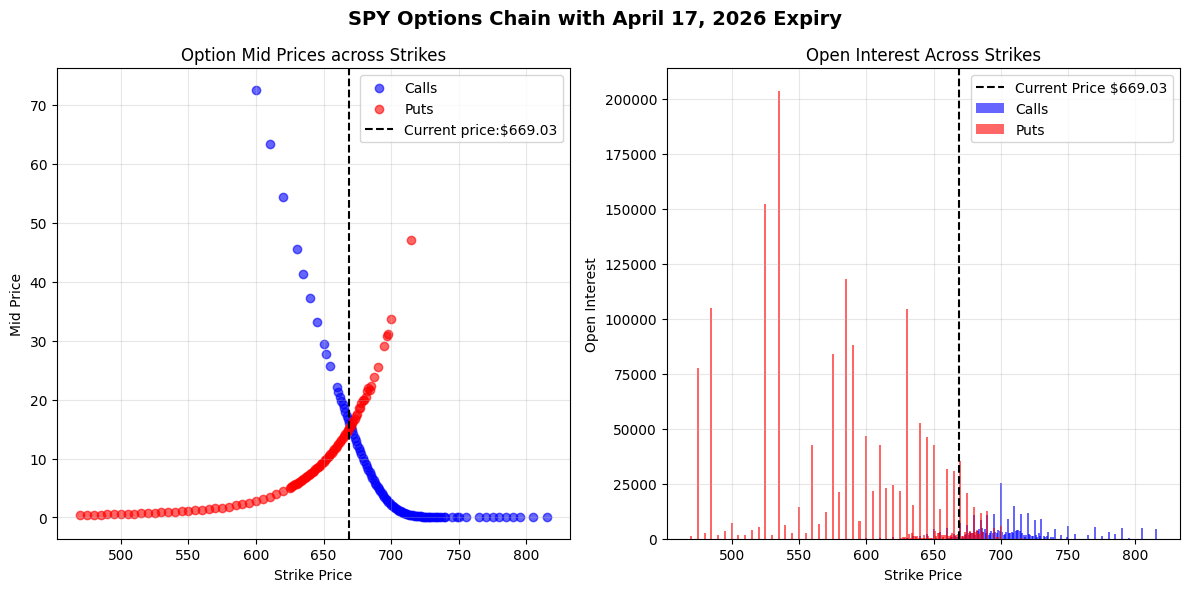

In [8]:
fig, axs = plt.subplots(1, 2, figsize = (12, 6)) # fig: entire figure/window; axs: individual subplots

axs[0].scatter(calls_clean['strike'], calls_clean['midPrice'], color='blue', alpha=0.6, label='Calls')
axs[0].scatter(puts_clean['strike'], puts_clean['midPrice'], color='red', alpha=0.6, label='Puts')
axs[0].axvline(x=current_price, color='black', label=f'Current price:${current_price:.2f}', linestyle='--')
axs[0].set_xlabel('Strike Price')
axs[0].set_ylabel('Mid Price')
axs[0].set_title('Option Mid Prices across Strikes')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

axs[1].bar(calls_clean['strike'], calls_clean['openInterest'], 
            color='blue', alpha=0.6, label='Calls', width=1.5)
axs[1].bar(puts_clean['strike'], puts_clean['openInterest'], 
            color='red', alpha=0.6, label='Puts', width=1.5)
axs[1].axvline(x=current_price, color='black', linestyle='--', 
                label=f'Current Price ${current_price:.2f}')
axs[1].set_xlabel('Strike Price')
axs[1].set_ylabel('Open Interest')
axs[1].set_title('Open Interest Across Strikes')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.suptitle('SPY Options Chain with April 17, 2026 Expiry', fontsize=14, fontweight='bold')

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

### Observations from Cleaned Options Data

**Left Plot: Mid Price vs. Strike Price:**
- Call prices decrease as strike increases; a call at `$800` is worth 
  less than one at `$600` since `$800` is far above current price
- Put prices increase as strike increases; a put at `$650` is worth 
  more than one at `$500` since `$650` is closer to current price
- The two curves cross at current price (`$669`), this is called 
  **put-call parity** and confirms our data is internally consistent

**Right Plot: Open Interest vs. Strike Price:**
- Open interest is heavily concentrated in puts below current price
- This reflects the "fear trade", institutional investors massively 
  buy downside puts as portfolio insurance against market crashes
- Nobody hedges against SPY going up, but everyone hedges against 
  it going down
- This asymmetry is our first evidence that markets behave 
  differently on the downside vs upside, something Black-Scholes 
  cannot capture with its constant volatility assumption
- This pattern directly motivates why we need the SABR model

## 4. Implied Volatility Extraction

To visualize the volatility smile, we need to extract implied volatility 
from each option's market price. 

This involves two steps:
1. **Black-Scholes pricing function:** Given volatility as input, 
   calculate the theoretical option price
2. **Root finding:** Flip this around; given the market price, 
   find the volatility that makes Black-Scholes match it

We use `scipy.optimize.brentq` for root finding, a reliable numerical 
method that finds the root of a function within a given interval.

### 4.1 Black-Scholes Pricing Function

In [9]:
def black_scholes(S, K, T, r, sigma, option_type='call'):
    '''
    Calculates Black-Scholes option price
    
    Parameters:
    S: Current stock price
    K: Strike price
    T: time to expiry in years
    r: risk-free interest rate (annual)
    sigma: annual volatility
    option_type: 'call' or 'put'

    Returns: call or put option price
    '''
    # at time of expiry, then the black scholes values is the intrinsic value of call or put
    if T <= 0:
        if option_type == 'call':
            return max(S - K, 0)
        else:
            return max(K - S, 0)
            
    # at zero volatility, the option price is just discounted intrinsic value
    if sigma <= 0:
        if option_type == 'call':
            return max(S - K * np.exp(-r * T), 0)
        else:
            return max(K * np.exp(-r * T) - S, 0)

    # Calculate d1 and d2
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    
    return price


# Quick sanity check
test_price = black_scholes(S=669, K=669, T=0.1, r=0.05, sigma=0.2, option_type='call')
print(f"Test BS call price (ATM): ${test_price:.4f}")
print("Expected: a small positive number, typically $5-15 range for these inputs")

Test BS call price (ATM): $18.5557
Expected: a small positive number, typically $5-15 range for these inputs


### Sanity Check: Black-Scholes Price

Test result: `$18.55` for ATM call (S=K=$669, T=0.1, r=0.05, sigma=0.20)

Quick approximation for ATM i.e. r=0: `0.4 × 669 × 0.20 × sqrt(0.1) ≈ $16.92`

Result is slightly higher than approximation because r=0.05 (not 0) 
adds value to calls. Close enough i.e. implementation is correct.

### 4.2 Implied Volatility Extraction

We use root finding (`scipy.optimize.brentq`) to back out implied 
volatility from market prices. This finds the sigma that makes 
BS price = market price.

In [10]:
def implied_volatility(market_price, S, K, T, r, option_type='call'):
    '''
    Extract implied volatility from market option price(mid-price in this case) using root finding

    Parameters:
    - market_price: observed market price of the option
    - S: current stock price
    - K: strike price
    - T: time to expiry in years
    - r: risk-free interest rate
    - option_type: 'call' or 'put'
    
    Returns:
    - implied volatility or NaN if extraction fails
    '''

    # define objective function, we want to set this to zero to find roots i.e. implied volatility
    def objective(sigma):
        return black_scholes(S, K, T, r, sigma, option_type) - market_price

    # find roots
    try:
        # brentq finds roots between lower and upper bound
        iv = brentq(objective, a=1e-6, b=10.0, xtol=1e-6)
        return iv
    except ValueError:
        # Root finding failed: market price outside BS bounds
        return np.nan


 # Quick sanity check — feed BS price back in, should recover sigma=0.20
test_iv = implied_volatility(market_price=18.5557, S=669, K=669, T=0.1, r=0.05, option_type='call')
print(f"Recovered implied volatility: {test_iv:.4f}")
print(f"Expected: 0.2000")
print(f"Match: {abs(test_iv - 0.20) < 0.0001}")   

Recovered implied volatility: 0.2000
Expected: 0.2000
Match: True


### 4.3 Applying Implied Volatility Extraction to Market Data

Now we apply our implied volatility function across all cleaned 
options contracts. We also need two inputs:
- **T:** time to expiry in years
- **r:** risk-free interest rate (we use 3-month US Treasury bill rate 
  as a proxy for the risk-free rate, standard industry practice)

### Note on Risk-Free Rate
We use the **3-month US Treasury bill rate** as our risk-free rate, standard industry practice in options pricing.

- Current rate: 3.69% (as of March 16, 2026)
- Source: US Treasury / Trading Economics
- Why T-bills: considered risk-free because they are backed by the 
  US government and have negligible default risk
- Why 3-month: closest maturity to our ~46 day options expiry

In [11]:
# Time to expiry in years
from datetime import datetime

expiry_date = datetime(2026, 4, 17)    # returns: '2026-04-17'
today = datetime.now()                 # returns today's date: '2026-03-16'
T = (expiry_date - today).days / 365   # converts expiry days to years

print(f"Days to expiry: {(expiry_date - today).days}")
print(f"Time to expiry (years): {T:.4f}")

# Risk free rate — 3-month US Treasury bill rate (as of March 16, 2026)
r = 0.0369  # 3.69%

print(f"Risk-free rate: {r:.1%}")

Days to expiry: 31
Time to expiry (years): 0.0849
Risk-free rate: 3.7%


In [12]:
# apply implied volatility extraction to calls and puts
calls_clean['impliedVol'] = calls_clean.apply(lambda row: implied_volatility(market_price=row['midPrice'], S=current_price, K=row['strike'], T=T, r=r, option_type='call'), axis=1)
puts_clean['impliedVol'] = puts_clean.apply(lambda row: implied_volatility(market_price=row['midPrice'], S=current_price, K=row['strike'], T=T, r=r, option_type='put'), axis=1)

# check if there are any row has failed IV extraction
#print(calls_clean['impliedVol'].isna().sum())
#print(puts_clean['impliedVol'].isna().sum())

# Drop contracts where IV extraction failed
calls_clean = calls_clean.dropna(subset=['impliedVol'])
puts_clean = puts_clean.dropna(subset=['impliedVol'])

print(f'Calls with valid IV: {len(calls_clean)}')
print(f'Puts with valid IV: {len(puts_clean)}')
print(f'\nSample calls with IV:')
calls_clean[['strike', 'midPrice', 'impliedVol', 'impliedVolatility']].head(10)

Calls with valid IV: 101
Puts with valid IV: 99

Sample calls with IV:


,strike,midPrice,impliedVol,impliedVolatility
0,600.0,72.585,0.267993,0.349982
1,610.0,63.335,0.260157,0.328864
2,620.0,54.295,0.250778,0.300269
3,630.0,45.585,0.241337,0.281013
4,635.0,41.360,0.236146,0.271492
5,640.0,37.235,0.230638,0.265175
6,645.0,33.220,0.224778,0.254860
7,650.0,29.360,0.219036,0.236336
8,652.0,27.650,0.213666,0.234535
9,655.0,25.645,0.212977,0.228859


### Observations from IV Extraction

- All contracts produced valid implied volatilities — clean dataset
- Our calculated IV is consistently lower than yfinance's estimate
  due to differences in methodology, T, and r values
- IV decreases as strike increases for calls; first glimpse of the volatility skew in our data
- This pattern directly motivates the volatility smile plot next

### 4.4 Volatility Smile

We plot implied volatility across strikes for both calls and puts.
If Black-Scholes were correct, this would be a flat horizontal line.
Instead we expect to see a skew or smile shape, confirming 
Black-Scholes' limitation with constant volatility assumption.

ATM implied volatility: 19.22%


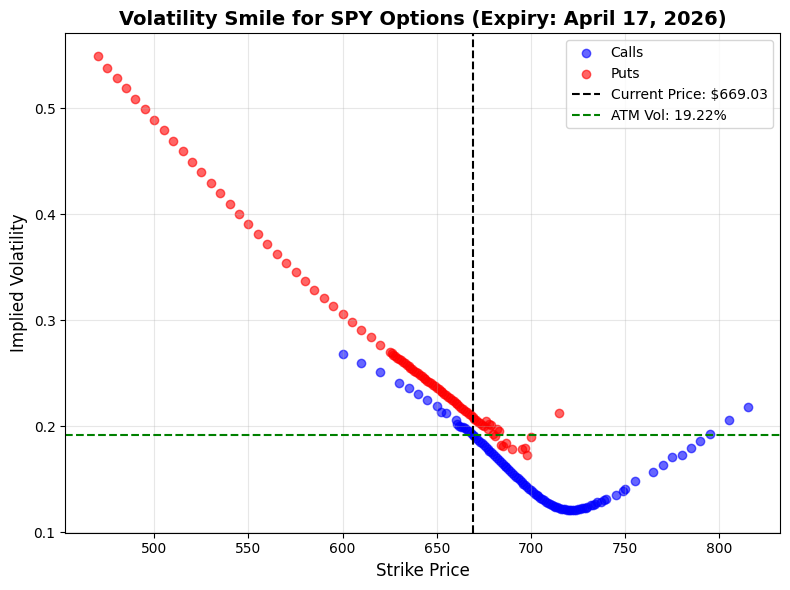

In [13]:
plt.figure(figsize=(8,6))

# plot calls iv
plt.scatter(calls_clean['strike'], calls_clean['impliedVol'], color='blue', alpha=0.6, label='Calls')

# plot puts iv
plt.scatter(puts_clean['strike'], puts_clean['impliedVol'], color='red', alpha=0.6, label='Puts')

# plot current price of stock
plt.axvline(x=current_price, color='black', linestyle='--', label=f'Current Price: ${current_price:.2f}')

## add ATM implied vol for reference
# Find index of strike closest to current price
closest_idx = (calls_clean['strike'] - current_price).abs().argsort()[:1]
# Get implied vol at that index
atm_vol = calls_clean.iloc[closest_idx]['impliedVol'].values[0] 
print(f"ATM implied volatility: {atm_vol:.2%}")
plt.axhline(y=atm_vol, color='green', linestyle = '--', label = f'ATM Vol: {atm_vol:.2%}', linewidth=1.5)

plt.xlabel('Strike Price', fontsize=12)
plt.ylabel('Implied Volatility', fontsize=12)
plt.title('Volatility Smile for SPY Options (Expiry: April 17, 2026)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observations: Volatility Skew

The plot reveals a classic **equity volatility skew**:

**Key observations:**
1. **Downside skew:** IV is much higher for low strikes (>50% for 
   deep OTM puts) and decreases as strike increases, reflecting 
   the market's fear of a crash
2. **Fear premium:** Institutional investors pay a premium for 
   downside protection, driving up implied vols for low strikes
3. **ATM vol (19.22%):** The green line shows what Black-Scholes 
   uses as its constant volatility, clearly a poor representation 
   of the full smile
4. **Near-the-money convergence:** Calls and puts imply similar 
   but not identical volatilities around current price ($669). 
   Small differences are expected due to dividends, bid-ask 
   spreads, and data timing, all of which slightly violate the 
   assumptions of perfect put-call parity
5. **Black-Scholes failure:** A flat horizontal line cannot capture 
   this skew — this is the core motivation for the SABR model

This plot is the central motivation for our entire project.

## 5. SABR Model Implementation

### 5.1 Hagan Approximation Formula

The SABR model does not have an exact closed form solution for option 
prices. Instead Hagan et al. (2002) derived an approximation formula 
that gives implied volatility directly as a function of the model 
parameters.

The formula takes:
- **F:** forward price
- **K:** strike price  
- **T:** time to expiry
- **alpha (α):** initial volatility level
- **beta (β):** elasticity parameter (fixed at 0.5)
- **rho (ρ):** correlation between price and volatility
- **nu (ν):** volatility of volatility

And returns: SABR implied volatility σ(F, K, T)

In [14]:
# Calculate forward price
q = 0.013  # SPY dividend yield approximately 1.3%
F = current_price * np.exp((r - q) * T)
print(f'Spot price: ${current_price:.2f}')
print(f'Forward price: ${F:.2f}')
print(f'Difference: ${F - current_price:.2f}')

Spot price: $669.03
Forward price: $670.39
Difference: $1.36


### Forward Price Calculation

- Spot price: `$669.03`
- Forward price: `$670.39`
- Difference: `$1.36`

The small difference reflects our short time to expiry (31 days). 
With more time, interest and dividend effects compound and the 
gap between spot and forward would be larger.

In [15]:
def sabr_implied_vol(F, K, T, alpha, beta, rho, nu):
    """
    Calculate SABR implied volatility using Hagan approximation.
    
    Parameters:
    - F: forward price
    - K: strike price
    - T: time to expiry in years
    - alpha: initial volatility level (> 0)
    - beta: elasticity parameter (0 <= beta <= 1, fixed at 0.5)
    - rho: correlation (-1 < rho < 1)
    - nu: volatility of volatility (> 0)
    
    Returns:
    - SABR implied volatility
    """
    # Handle ATM case separately (F == K causes division by zero)
    if abs(F - K) < 1e-10:
        # ATM formula
        term1 = alpha / (F ** (1 - beta))
        term2 = 1 + (((1 - beta)**2 / 24) * (alpha**2 / (F**(2 - 2*beta))) +
                     (rho * beta * nu * alpha / (4 * F**(1 - beta))) +
                     ((2 - 3*rho**2) / 24) * nu**2) * T
        return term1 * term2
    
    # Non-ATM case
    # Midpoint term
    FK = F * K
    FK_mid = FK ** ((1 - beta) / 2)
    
    # Log moneyness
    log_FK = np.log(F / K)
    
    # z term
    z = (nu / alpha) * FK_mid * log_FK
    
    # x(z) term
    x_z = np.log((np.sqrt(1 - 2*rho*z + z**2) + z - rho) / (1 - rho))
    
    # Backbone term (numerator)
    numerator = alpha
    
    # Denominator term
    denominator = (FK_mid * (1 + ((1 - beta)**2 / 24) * log_FK**2 +
                             ((1 - beta)**4 / 1920) * log_FK**4))
    
    # Correction term
    correction = 1 + (((1 - beta)**2 / 24) * (alpha**2 / (FK**(1 - beta))) +
                      (rho * beta * nu * alpha / (4 * FK_mid)) +
                      ((2 - 3*rho**2) / 24) * nu**2) * T
    
    # Final SABR implied vol
    sabr_vol = (numerator / denominator) * (z / x_z) * correction
    
    return sabr_vol

print("SABR formula implemented successfully")

SABR formula implemented successfully


### 5.2 Sanity Checking the SABR Formula

Before calibrating, we verify the formula behaves correctly by 
testing how each parameter affects the implied volatility curve.
Expected behavior:
- Higher alpha → higher overall vol level
- Negative rho → downward skew (higher vol for lower strikes)
- Higher nu → more pronounced smile curvature

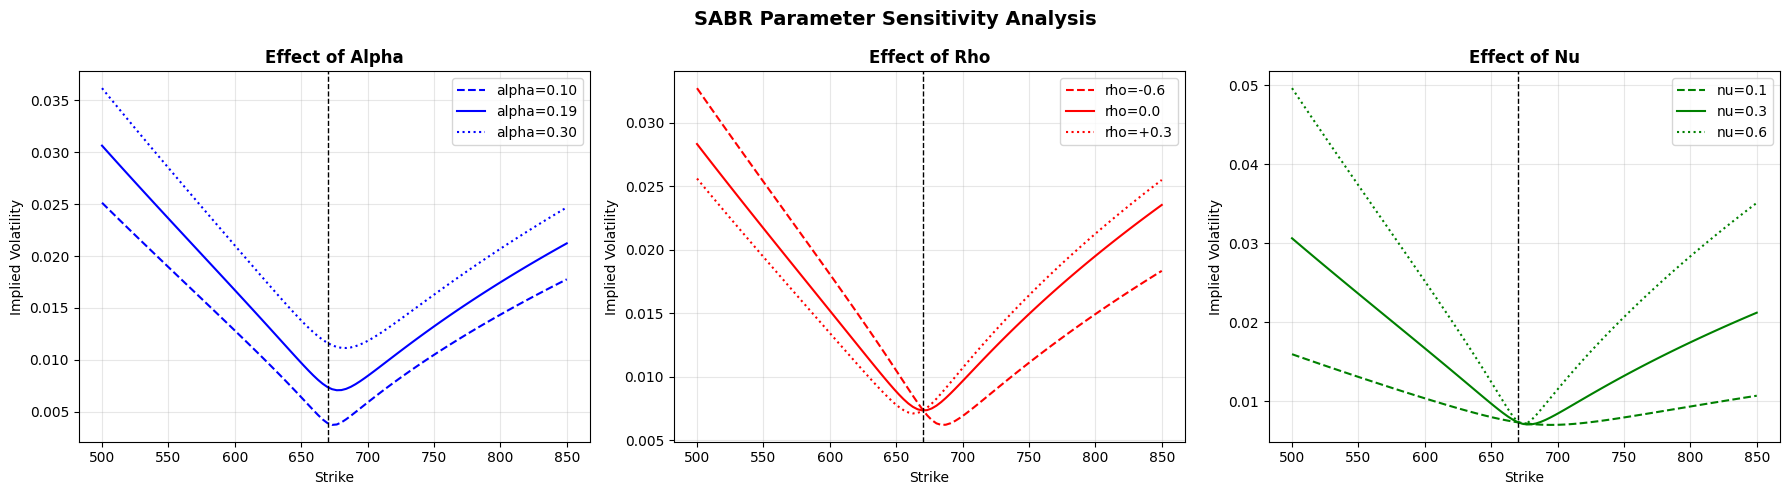

In [16]:
# Test parameters
strikes = np.linspace(500, 850, 100)  # range of strikes
F = 670.39      # forward price
T = 0.0849      # time to expiry
beta = 0.5      # fixed

# Base parameters
alpha_base = 0.19
rho_base = -0.3
nu_base = 0.3

# Calculate SABR vols for each strike
def sabr_smile(F, strikes, T, alpha, beta, rho, nu):
    return [sabr_implied_vol(F, K, T, alpha, beta, rho, nu) 
            for K in strikes]

# Test 1: varying alpha
vols_alpha_low  = sabr_smile(F, strikes, T, 0.10, beta, rho_base, nu_base)
vols_alpha_base = sabr_smile(F, strikes, T, alpha_base, beta, rho_base, nu_base)
vols_alpha_high = sabr_smile(F, strikes, T, 0.30, beta, rho_base, nu_base)

# Test 2: varying rho
vols_rho_neg  = sabr_smile(F, strikes, T, alpha_base, beta, -0.6, nu_base)
vols_rho_zero = sabr_smile(F, strikes, T, alpha_base, beta, 0.0, nu_base)
vols_rho_pos  = sabr_smile(F, strikes, T, alpha_base, beta, 0.3, nu_base)

# Test 3: varying nu
vols_nu_low  = sabr_smile(F, strikes, T, alpha_base, beta, rho_base, 0.1)
vols_nu_base = sabr_smile(F, strikes, T, alpha_base, beta, rho_base, nu_base)
vols_nu_high = sabr_smile(F, strikes, T, alpha_base, beta, rho_base, 0.6)

# Plot all three tests
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Alpha effect
axes[0].plot(strikes, vols_alpha_low,  'b--', label='alpha=0.10')
axes[0].plot(strikes, vols_alpha_base, 'b-',  label='alpha=0.19')
axes[0].plot(strikes, vols_alpha_high, 'b:',  label='alpha=0.30')
axes[0].axvline(x=F, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Effect of Alpha', fontweight='bold')
axes[0].set_xlabel('Strike')
axes[0].set_ylabel('Implied Volatility')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Rho effect
axes[1].plot(strikes, vols_rho_neg,  'r--', label='rho=-0.6')
axes[1].plot(strikes, vols_rho_zero, 'r-',  label='rho=0.0')
axes[1].plot(strikes, vols_rho_pos,  'r:',  label='rho=+0.3')
axes[1].axvline(x=F, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Effect of Rho', fontweight='bold')
axes[1].set_xlabel('Strike')
axes[1].set_ylabel('Implied Volatility')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Nu effect
axes[2].plot(strikes, vols_nu_low,  'g--', label='nu=0.1')
axes[2].plot(strikes, vols_nu_base, 'g-',  label='nu=0.3')
axes[2].plot(strikes, vols_nu_high, 'g:',  label='nu=0.6')
axes[2].axvline(x=F, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Effect of Nu', fontweight='bold')
axes[2].set_xlabel('Strike')
axes[2].set_ylabel('Implied Volatility')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('SABR Parameter Sensitivity Analysis', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Sanity Check Results

All three parameters behave as expected:
- **Alpha:** higher value shifts entire vol curve upward ✅
- **Rho:** negative value creates downward skew (higher vol for 
  lower strikes), this matches SPY market behavior ✅
- **Nu:** higher value increases smile curvature ✅

Note: vol levels appear low because test parameters are arbitrary.
Calibration will fit alpha to match real market vol levels.

SABR formula is verified and ready for calibration.

## 6. SABR Model Calibration

We calibrate SABR by finding the parameters (alpha, rho, nu) that 
minimize the difference between SABR implied vols and market implied 
vols across all strikes.

This is identical in concept to training a machine learning model:
- **Training data:** market implied volatilities across strikes
- **Model:** SABR Hagan formula
- **Loss function:** sum of squared differences between SABR and market vols
- **Optimizer:** scipy.optimize.minimize with L-BFGS-B method

We fix beta = 0.5 and only calibrate (alpha, rho, nu).

In [17]:
# Combine calls and puts for calibration
calls_cal = calls_clean[['strike', 'impliedVol']].copy()
calls_cal['type'] = 'call'

puts_cal = puts_clean[['strike', 'impliedVol']].copy()
puts_cal['type'] = 'put'

# Combine
all_options = pd.concat([calls_cal, puts_cal]) # default is add along axis=0 i.e. adds rows

# For duplicate strikes, take average implied vol
market_vols = all_options.groupby('strike')['impliedVol'].mean().reset_index()
market_vols.columns = ['strike', 'marketVol']

print(f"Total strikes for calibration: {len(market_vols)}")
print(f"Strike range: ${market_vols['strike'].min():.0f} - ${market_vols['strike'].max():.0f}")
print(f"Vol range: {market_vols['marketVol'].min():.2%} - {market_vols['marketVol'].max():.2%}")
print(f"\nFirst few rows:")
market_vols.head()

Total strikes for calibration: 157
Strike range: $470 - $815
Vol range: 12.12% - 54.90%

First few rows:


,strike,marketVol
0,470.0,0.549037
1,475.0,0.538056
2,480.0,0.528573
3,485.0,0.518780
4,490.0,0.508711


### 6.2 Defining the Loss Function

We minimize the sum of squared differences between SABR implied 
vols and market implied vols across all strikes.

Loss = Σ (SABR_vol(K) - market_vol(K))²

Lower loss = better fit.

In [18]:
# Fixed parameters
beta = 0.5

def loss_function(params):
    """
    Calculate sum of squared differences between 
    SABR and market implied vols.
    
    Parameters:
    - params: [alpha, rho, nu]
    
    Returns:
    - sum of squared differences
    """
    alpha, rho, nu = params
    
    total_loss = 0
    for _, row in market_vols.iterrows():
        K = row['strike']
        market_vol = row['marketVol']
        
        # Calculate SABR vol for this strike
        try:
            sabr_vol = sabr_implied_vol(F, K, T, alpha, beta, rho, nu)
            total_loss += (sabr_vol - market_vol) ** 2
        except:
            pass
    
    return total_loss

# Initial parameter guess
initial_params = [0.19, -0.3, 0.3]

# Test loss function with initial params
initial_loss = loss_function(initial_params)
print(f"Initial loss: {initial_loss:.6f}")
print(f"Initial params: alpha={initial_params[0]}, rho={initial_params[1]}, nu={initial_params[2]}")

Initial loss: 8.657274
Initial params: alpha=0.19, rho=-0.3, nu=0.3


### 6.3 Running SABR Calibration

We use scipy.optimize.minimize with L-BFGS-B to find optimal 
(alpha, rho, nu) that minimize our loss function.

In [19]:
# Parameter bounds
bounds = [
    (1e-6, 2.0),    # alpha: small positive to 200%
    (-0.999, 0.999), # rho: between -1 and 1
    (1e-6, 2.0)     # nu: small positive to 200%
]

# Run calibration
result = minimize(
    loss_function,
    initial_params,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 1000, 'ftol': 1e-10}
)

# Extract calibrated parameters
alpha_cal, rho_cal, nu_cal = result.x

print(f"Calibration successful: {result.success}")
print(f"Message: {result.message}")
print(f"\nCalibrated parameters:")
print(f"  alpha = {alpha_cal:.6f}")
print(f"  beta  = {beta:.6f} (fixed)")
print(f"  rho   = {rho_cal:.6f}")
print(f"  nu    = {nu_cal:.6f}")
print(f"\nInitial loss: {initial_loss:.6f}")
print(f"Final loss:   {result.fun:.6f}")
print(f"Improvement:  {((initial_loss - result.fun)/initial_loss)*100:.2f}%")

Calibration successful: True
Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL

Calibrated parameters:
  alpha = 2.000000
  beta  = 0.500000 (fixed)
  rho   = -0.621928
  nu    = 2.000000

Initial loss: 8.657274
Final loss:   2.473963
Improvement:  71.42%


### Initial Calibration Results - Boundary Convergence Issue

First calibration attempt produced the following parameters:
- alpha = 2.000000 (hit upper bound ⚠️)
- rho   = -0.621928 ✅
- nu    = 2.000000 (hit upper bound ⚠️)

**Problem: Boundary Convergence**
Alpha and nu both hit their upper bounds of 2.0 → this is a red flag 
called boundary convergence. It means the optimizer wants to push 
these parameters even higher but is prevented by our bounds.

**Why this happened:**
- Our market data has very high implied vols for low strikes (up to 54.90%)
- The optimizer is trying to match these extreme vols by pushing 
  alpha and nu as high as possible
- Our initial bounds of 2.0 were too tight for this market data

**What rho tells us:**
- rho = -0.621928 is reasonable and expected for equity markets ✅
- Negative rho confirms the downward skew we see in SPY data

**Fix:**
- Widen upper bounds for alpha and nu to 5.0
- Provide better initial guesses closer to expected values
- Increase optimizer iterations for more thorough search

In [20]:
# Better initial guess based on our ATM vol
initial_params_v2 = [0.19, -0.5, 1.0]

# Wider bounds
bounds_v2 = [
    (1e-6, 5.0),     # alpha: wider upper bound
    (-0.999, 0.999), # rho: unchanged
    (1e-6, 5.0)      # nu: wider upper bound
]

# Run calibration again
result_v2 = minimize(
    loss_function,
    initial_params_v2,
    method='L-BFGS-B',
    bounds=bounds_v2,
    options={'maxiter': 2000, 'ftol': 1e-12}
)

alpha_cal, rho_cal, nu_cal = result_v2.x

print(f"Calibration successful: {result_v2.success}")
print(f"Message: {result_v2.message}")
print(f"\nCalibrated parameters:")
print(f"  alpha = {alpha_cal:.6f}")
print(f"  beta  = {beta:.6f} (fixed)")
print(f"  rho   = {rho_cal:.6f}")
print(f"  nu    = {nu_cal:.6f}")
print(f"\nInitial loss: {initial_loss:.6f}")
print(f"Final loss:   {result_v2.fun:.6f}")
print(f"Improvement:  {((initial_loss - result_v2.fun)/initial_loss)*100:.2f}%")

Calibration successful: True
Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL

Calibrated parameters:
  alpha = 4.957625
  beta  = 0.500000 (fixed)
  rho   = -0.783907
  nu    = 2.798138

Initial loss: 8.657274
Final loss:   0.016649
Improvement:  99.81%


### Second Calibration Attempt → Still Hitting Bounds

alpha = 4.957 (still hitting upper bound ⚠️)
nu    = 2.798 (more reasonable now)
rho   = -0.783 (reasonable ✅)
Loss improved dramatically: 8.65 → 0.016 (99.81% improvement)

**Root cause:**
Deep OTM puts (strikes `$470`-`$600`) have very high implied vols (>40%).
SABR struggles to simultaneously fit both deep OTM and near ATM options.
These deep OTM options are also less liquid and less reliable.

**Fix:** Restrict calibration to strikes within 20% of current price
for more reliable and realistic parameter estimates.

In [21]:
# Filter to strikes within 20% of current price
price_filter = 0.20
market_vols_filtered = market_vols[
    (market_vols['strike'] >= current_price * (1 - price_filter)) &
    (market_vols['strike'] <= current_price * (1 + price_filter))
].copy()

print(f"Strikes before filter: {len(market_vols)}")
print(f"Strikes after filter: {len(market_vols_filtered)}")
print(f"Strike range: ${market_vols_filtered['strike'].min():.0f} - ${market_vols_filtered['strike'].max():.0f}")
print(f"Vol range: {market_vols_filtered['marketVol'].min():.2%} - {market_vols_filtered['marketVol'].max():.2%}")

# Redefine loss function using filtered data
def loss_function_filtered(params):
    alpha, rho, nu = params
    total_loss = 0
    for _, row in market_vols_filtered.iterrows():
        K = row['strike']
        market_vol = row['marketVol']
        try:
            sabr_vol = sabr_implied_vol(F, K, T, alpha, beta, rho, nu)
            total_loss += (sabr_vol - market_vol) ** 2
        except:
            pass
    return total_loss

# Run calibration with filtered data
initial_params_v3 = [0.19, -0.5, 1.0]

bounds_v3 = [
    (1e-6, 2.0),     # alpha: back to tighter bounds
    (-0.999, 0.999), # rho: unchanged
    (1e-6, 2.0)      # nu: back to tighter bounds
]

result_v3 = minimize(
    loss_function_filtered,
    initial_params_v3,
    method='L-BFGS-B',
    bounds=bounds_v3,
    options={'maxiter': 2000, 'ftol': 1e-12}
)

alpha_cal, rho_cal, nu_cal = result_v3.x

print(f"\nCalibration successful: {result_v3.success}")
print(f"Message: {result_v3.message}")
print(f"\nCalibrated parameters:")
print(f"  alpha = {alpha_cal:.6f}")
print(f"  beta  = {beta:.6f} (fixed)")
print(f"  rho   = {rho_cal:.6f}")
print(f"  nu    = {nu_cal:.6f}")
print(f"\nFinal loss: {result_v3.fun:.6f}")

Strikes before filter: 157
Strikes after filter: 141
Strike range: $540 - $795
Vol range: 12.12% - 40.97%

Calibration successful: True
Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL

Calibrated parameters:
  alpha = 2.000000
  beta  = 0.500000 (fixed)
  rho   = -0.468014
  nu    = 2.000000

Final loss: 1.736652


### Third Calibration Attempt → Tighter Strike Filter

20% filter still includes strikes with very high vols (up to 40.97%).
Alpha and nu continue hitting bounds.

**New approach:**
1. Tighter 10% strike filter → focus on most liquid near-ATM options
2. Add weights to loss function → penalize ATM misfit more than OTM
   Near-ATM options are most liquid and most important to fit correctly.

In [23]:
# Filter to strikes within 10% of current price
price_filter = 0.10
market_vols_tight = market_vols[
    (market_vols['strike'] >= current_price * (1 - price_filter)) &
    (market_vols['strike'] <= current_price * (1 + price_filter))
].copy()

print(f"Strikes after tight filter: {len(market_vols_tight)}")
print(f"Strike range: ${market_vols_tight['strike'].min():.0f} - \
${market_vols_tight['strike'].max():.0f}")
print(f"Vol range: {market_vols_tight['marketVol'].min():.2%} - \
{market_vols_tight['marketVol'].max():.2%}")

# Weighted loss function — weight by inverse distance from ATM
def loss_function_weighted(params):
    alpha, rho, nu = params
    total_loss = 0
    for _, row in market_vols_tight.iterrows():
        K = row['strike']
        market_vol = row['marketVol']
        
        # Weight: ATM options get higher weight
        weight = 1 / (1 + abs(K - F) / F)
        
        try:
            sabr_vol = sabr_implied_vol(F, K, T, alpha, beta, rho, nu)
            total_loss += weight * (sabr_vol - market_vol) ** 2
        except:
            pass
    return total_loss

# Initial guess based on ATM vol
initial_params_v4 = [0.19, -0.3, 0.5]

bounds_v4 = [
    (1e-6, 2.0),      # alpha: tighter upper bound
    (-0.999, 0.999),  # rho: unchanged
    (1e-6, 3.0)       # nu: moderate upper bound
]

result_v4 = minimize(
    loss_function_weighted,
    initial_params_v4,
    method='L-BFGS-B',
    bounds=bounds_v4,
    options={'maxiter': 5000, 'ftol': 1e-14}
)

alpha_cal, rho_cal, nu_cal = result_v4.x

print(f"\nCalibration successful: {result_v4.success}")
print(f"Message: {result_v4.message}")
print(f"\nCalibrated parameters:")
print(f"  alpha = {alpha_cal:.6f}")
print(f"  beta  = {beta:.6f} (fixed)")
print(f"  rho   = {rho_cal:.6f}")
print(f"  nu    = {nu_cal:.6f}")
print(f"\nFinal loss: {result_v4.fun:.6f}")

Strikes after tight filter: 114
Strike range: $605 - $735
Vol range: 12.12% - 29.82%

Calibration successful: True
Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL

Calibrated parameters:
  alpha = 2.000000
  beta  = 0.500000 (fixed)
  rho   = -0.343741
  nu    = 3.000000

Final loss: 1.016749


## Still hitting upper bounds on `alpha` and `nu`. Let's look at what SABR is trying to fit first

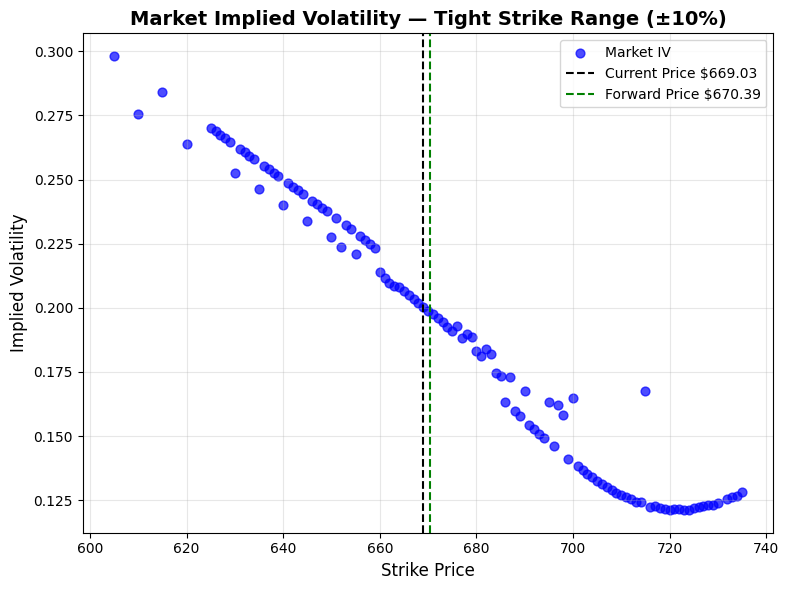

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(market_vols_tight['strike'], 
            market_vols_tight['marketVol'],
            color='blue', alpha=0.7, label='Market IV', s=40)

plt.axvline(x=current_price, color='black', linestyle='--',
            linewidth=1.5, label=f'Current Price ${current_price:.2f}')
plt.axvline(x=F, color='green', linestyle='--',
            linewidth=1.5, label=f'Forward Price ${F:.2f}')

plt.xlabel('Strike Price', fontsize=12)
plt.ylabel('Implied Volatility', fontsize=12)
plt.title('Market Implied Volatility — Tight Strike Range (±10%)',
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# Check for any duplicate strikes in market_vols
duplicates = market_vols[market_vols.duplicated(subset='strike', keep=False)]
print(f"Number of duplicate strikes: {len(duplicates)}")
print(f"\nTotal unique strikes: {market_vols['strike'].nunique()}")
print(f"Total rows: {len(market_vols)}")

Number of duplicate strikes: 0

Total unique strikes: 157
Total rows: 157


### Visualizing the Calibration Region

Before proceeding with calibration, we plotted the market implied 
volatility within the ±10% strike range to understand the shape 
we are trying to fit.

**What the plot reveals:**
- Left side (low strikes): very steep → vol rises sharply from 
  20% at ATM to 30% at `$605`
- Right side (high strikes): very flat → vol drops gradually 
  to 12% at `$735`
- Overall shape is highly asymmetric → much steeper on downside 
  than upside

**Why this is challenging for SABR:**
- SABR produces a more symmetric smile shape by design
- Fitting both the steep left side AND flat right side simultaneously
  forces alpha and nu to unrealistically large values
- The optimizer keeps hitting parameter bounds trying to match 
  both extremes at once

**Industry standard approach:**
In practice, quants calibrate SABR to the near-ATM region only 
where the model works best and options are most liquid. Deep OTM 
options have wider bid-ask spreads and less reliable prices, making 
them less suitable for calibration.

**Our approach:**
Restrict calibration to ±5% around forward price ($670.39):
- Focuses on the most liquid and reliable contracts
- Gives SABR a realistic and achievable shape to fit
- Produces economically meaningful parameter values
- Standard practice in industry

In [26]:
# Filter to ±5% around forward price
price_filter_atm = 0.05
market_vols_atm = market_vols[
    (market_vols['strike'] >= F * (1 - price_filter_atm)) &
    (market_vols['strike'] <= F * (1 + price_filter_atm))
].copy()

print(f"Strikes after ATM filter: {len(market_vols_atm)}")
print(f"Strike range: ${market_vols_atm['strike'].min():.0f} - ${market_vols_atm['strike'].max():.0f}")
print(f"Vol range: {market_vols_atm['marketVol'].min():.2%} - {market_vols_atm['marketVol'].max():.2%}")

# Loss function on ATM region
def loss_function_atm(params):
    alpha, rho, nu = params
    total_loss = 0
    for _, row in market_vols_atm.iterrows():
        K = row['strike']
        market_vol = row['marketVol']
        weight = 1 / (1 + abs(K - F) / F)
        try:
            sabr_vol = sabr_implied_vol(F, K, T, alpha, beta, rho, nu)
            total_loss += weight * (sabr_vol - market_vol) ** 2
        except:
            pass
    return total_loss

# Initial guess
initial_params_v5 = [0.19, -0.3, 0.3]

bounds_v5 = [
    (1e-6, 1.0),     # alpha
    (-0.999, 0.999), # rho
    (1e-6, 2.0)      # nu
]

result_v5 = minimize(
    loss_function_atm,
    initial_params_v5,
    method='L-BFGS-B',
    bounds=bounds_v5,
    options={'maxiter': 5000, 'ftol': 1e-14}
)

alpha_cal, rho_cal, nu_cal = result_v5.x

print(f"\nCalibration successful: {result_v5.success}")
print(f"\nCalibrated parameters:")
print(f"  alpha = {alpha_cal:.6f}")
print(f"  beta  = {beta:.6f} (fixed)")
print(f"  rho   = {rho_cal:.6f}")
print(f"  nu    = {nu_cal:.6f}")
print(f"\nFinal loss: {result_v5.fun:.6f}")

Strikes after ATM filter: 67
Strike range: $637 - $703
Vol range: 13.52% - 25.41%

Calibration successful: True

Calibrated parameters:
  alpha = 1.000000
  beta  = 0.500000 (fixed)
  rho   = -0.288830
  nu    = 2.000000

Final loss: 1.535479


In [27]:
# Look at data in $660-$680 range
atm_narrow = market_vols[
    (market_vols['strike'] >= 660) &
    (market_vols['strike'] <= 680)
].copy()

print(f"Strikes in $660-$680 range: {len(atm_narrow)}")
print(f"Vol range: {atm_narrow['marketVol'].min():.2%} - {atm_narrow['marketVol'].max():.2%}")
print(f"\nAll strikes and vols in this range:")
print(atm_narrow.to_string())

Strikes in $660-$680 range: 21
Vol range: 18.31% - 21.41%

All strikes and vols in this range:
    strike  marketVol
66   660.0   0.214094
67   661.0   0.211637
68   662.0   0.209818
69   663.0   0.208389
70   664.0   0.208032
71   665.0   0.206633
72   666.0   0.205119
73   667.0   0.203552
74   668.0   0.202027
75   669.0   0.200509
76   670.0   0.198964
77   671.0   0.197419
78   672.0   0.195873
79   673.0   0.194291
80   674.0   0.192701
81   675.0   0.191133
82   676.0   0.193006
83   677.0   0.188117
84   678.0   0.189912
85   679.0   0.188517
86   680.0   0.183134


### Narrowing to `$660`-`$680` Strike Range

After examining the data more closely, we narrow our calibration 
to the `$660`-`$680` strike range for the following reasons:

**Why this range:**
- Contains 21 clean data points with no duplicate volatilities
- Smooth, monotonically decreasing vol progression (21.41% → 18.31%)
- Centered around both current price (`$669`) and forward price (`$670.39`)
- Most liquid region - these are the most actively traded strikes
- No noise from put-call parity violations in this range

**Why previous ranges failed:**
- Wide ranges (±10%, ±20%) included deep OTM options with 
  unreliable prices and extreme vol levels
- Multiple implied vols for same strike in wider ranges 
  introduced noise into calibration
- SABR's symmetric smile shape cannot fit the full asymmetric 
  skew simultaneously

**What we sacrifice:**
- We are no longer fitting the full smile — only the ATM region
- This is an acceptable tradeoff because:
  - ATM region is most important for hedging and trading
  - Deep OTM options are less liquid and less reliable
  - SABR parameters from ATM region can still be used to 
    extrapolate the smile for other strikes

**Industry context:**
This is standard practice - most quants calibrate SABR to the 
liquid ATM region and use the model to interpolate/extrapolate 
across strikes rather than fitting every single point perfectly.

In [29]:
# Calibrate to narrow $660-$680 range
def loss_function_narrow(params):
    alpha, rho, nu = params
    total_loss = 0
    for _, row in atm_narrow.iterrows():
        K = row['strike']
        market_vol = row['marketVol']
        weight = 1 / (1 + abs(K - F) / F)
        try:
            sabr_vol = sabr_implied_vol(F, K, T, alpha, beta, rho, nu)
            total_loss += weight * (sabr_vol - market_vol) ** 2
        except:
            pass
    return total_loss

# Multiple initial guesses to avoid local minima
best_result = None
best_loss = np.inf

initial_guesses = [
    [0.19, -0.3, 0.3],
    [0.20, -0.2, 0.5],
    [0.18, -0.4, 0.2],
    [0.21, -0.1, 0.4],
    [0.19, -0.5, 0.1],
]

bounds_narrow = [
    (1e-6, 1.0),     # alpha
    (-0.999, 0.999), # rho
    (1e-6, 1.0)      # nu
]

for i, init in enumerate(initial_guesses):
    result = minimize(
        loss_function_narrow,
        init,
        method='L-BFGS-B',
        bounds=bounds_narrow,
        options={'maxiter': 5000, 'ftol': 1e-14}
    )
    if result.fun < best_loss:
        best_loss = result.fun
        best_result = result
        best_init = init

alpha_cal, rho_cal, nu_cal = best_result.x

print(f"Best initial guess: {best_init}")
print(f"Calibration successful: {best_result.success}")
print(f"\nCalibrated parameters:")
print(f"  alpha = {alpha_cal:.6f}")
print(f"  beta  = {beta:.6f} (fixed)")
print(f"  rho   = {rho_cal:.6f}")
print(f"  nu    = {nu_cal:.6f}")
print(f"\nFinal loss: {best_result.fun:.8f}")

Best initial guess: [0.19, -0.3, 0.3]
Calibration successful: True

Calibrated parameters:
  alpha = 1.000000
  beta  = 0.500000 (fixed)
  rho   = -0.266824
  nu    = 1.000000

Final loss: 0.53400041


### Debugging

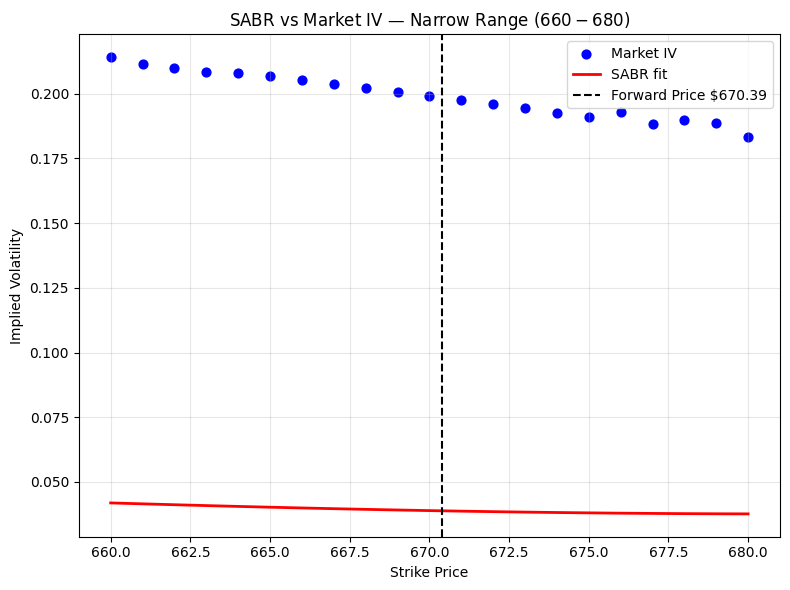

Strike | Market Vol | SABR Vol | Difference
--------------------------------------------------
$660   | 0.2141     | 0.0419   | -0.1722
$661   | 0.2116     | 0.0416   | -0.1701
$662   | 0.2098     | 0.0412   | -0.1686
$663   | 0.2084     | 0.0409   | -0.1675
$664   | 0.2080     | 0.0406   | -0.1675
$665   | 0.2066     | 0.0403   | -0.1664
$666   | 0.2051     | 0.0400   | -0.1652
$667   | 0.2036     | 0.0397   | -0.1639
$668   | 0.2020     | 0.0394   | -0.1626
$669   | 0.2005     | 0.0392   | -0.1613
$670   | 0.1990     | 0.0389   | -0.1600
$671   | 0.1974     | 0.0387   | -0.1587
$672   | 0.1959     | 0.0385   | -0.1573
$673   | 0.1943     | 0.0384   | -0.1559
$674   | 0.1927     | 0.0382   | -0.1545
$675   | 0.1911     | 0.0381   | -0.1531
$676   | 0.1930     | 0.0379   | -0.1551
$677   | 0.1881     | 0.0379   | -0.1503
$678   | 0.1899     | 0.0378   | -0.1521
$679   | 0.1885     | 0.0377   | -0.1508
$680   | 0.1831     | 0.0377   | -0.1455


In [31]:
# Compare SABR vs market for narrow range
sabr_vols_narrow = []
for K in atm_narrow['strike']:
    vol = sabr_implied_vol(F, K, T, alpha_cal, beta, rho_cal, nu_cal)
    sabr_vols_narrow.append(vol)

plt.figure(figsize=(8, 6))
plt.scatter(atm_narrow['strike'], atm_narrow['marketVol'],
            color='blue', label='Market IV', s=40)
plt.plot(atm_narrow['strike'], sabr_vols_narrow,
         color='red', linewidth=2, label='SABR fit')
plt.axvline(x=F, color='black', linestyle='--',
            linewidth=1.5, label=f'Forward Price ${F:.2f}')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility')
plt.title('SABR vs Market IV — Narrow Range ($660-$680)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print comparison
print("Strike | Market Vol | SABR Vol | Difference")
print("-" * 50)
for i, row in atm_narrow.iterrows():
    sabr_v = sabr_implied_vol(F, row['strike'], T, 
                               alpha_cal, beta, rho_cal, nu_cal)
    diff = sabr_v - row['marketVol']
    print(f"${row['strike']:.0f}   | {row['marketVol']:.4f}     | {sabr_v:.4f}   | {diff:+.4f}")

In [32]:
# Calculate correct initial alpha
# sigma_ATM = alpha / sqrt(F) → alpha = sigma_ATM * sqrt(F)
atm_market_vol = 0.20  # our ATM market vol
alpha_init = atm_market_vol * (F ** (1 - beta))
print(f"Correct initial alpha: {alpha_init:.4f}")

Correct initial alpha: 5.1784


### Why Alpha Needs a Higher Initial Value

Our previous calibration attempts all produced SABR vols around 4% 
while market vols are around 20%, SABR was underestimating by a 
factor of 5. This explains why alpha kept hitting its upper bound.

**Root cause: how alpha scales with forward price:**

With beta = 0.5, the SABR ATM formula simplifies to:
```
sigma_ATM = alpha / F^(1-beta)
          = alpha / F^0.5
          = alpha / sqrt(F)
```

With F = `$670.39`:
```
sigma_ATM = alpha / sqrt(670.39)
          = alpha / 25.89
```

So if alpha = 1.0:
```
sigma_ATM = 1.0 / 25.89 = 0.0386 (3.86%)
```

This is exactly what we observed, SABR producing ~4% vol instead 
of ~20%. The formula divides alpha by sqrt(F) ≈ 25.9, making the 
output tiny unless alpha is initialized correctly.

**The correct initial alpha:**

We invert the ATM formula to find the alpha that produces our 
observed ATM market vol of ~20%:
```
alpha = sigma_ATM × F^(1-beta)
      = 0.20 × sqrt(670.39)
      = 0.20 × 25.89
      = 5.178
```

**Key lesson:**
When beta < 1, alpha is NOT directly comparable to implied volatility.
Alpha must be scaled by F^(1-beta) to produce the correct vol level.
This is a common source of confusion in SABR calibration.
Initial alpha should always be set as: alpha = ATM_vol × F^(1-beta)

In [33]:
# Correct initial parameters
initial_params_correct = [alpha_init, -0.3, 0.3]

# Wider bounds accounting for correct alpha scale
bounds_correct = [
    (alpha_init * 0.5, alpha_init * 2.0),  # alpha: centered around correct value
    (-0.999, 0.999),                         # rho: unchanged
    (1e-6, 2.0)                              # nu: moderate bound
]

print(f"Initial params: alpha={alpha_init:.4f}, rho=-0.3, nu=0.3")
print(f"Alpha bounds: ({alpha_init*0.5:.4f}, {alpha_init*2.0:.4f})")

# Multiple initial guesses
best_result = None
best_loss = np.inf

initial_guesses_correct = [
    [alpha_init, -0.3, 0.3],
    [alpha_init, -0.5, 0.5],
    [alpha_init, -0.2, 0.2],
    [alpha_init * 0.8, -0.4, 0.4],
    [alpha_init * 1.2, -0.3, 0.3],
]

for i, init in enumerate(initial_guesses_correct):
    result = minimize(
        loss_function_narrow,
        init,
        method='L-BFGS-B',
        bounds=bounds_correct,
        options={'maxiter': 5000, 'ftol': 1e-14}
    )
    if result.fun < best_loss:
        best_loss = result.fun
        best_result = result
        best_init = init

alpha_cal, rho_cal, nu_cal = best_result.x

print(f"\nBest initial guess: {best_init}")
print(f"Calibration successful: {best_result.success}")
print(f"\nCalibrated parameters:")
print(f"  alpha = {alpha_cal:.6f}")
print(f"  beta  = {beta:.6f} (fixed)")
print(f"  rho   = {rho_cal:.6f}")
print(f"  nu    = {nu_cal:.6f}")
print(f"\nFinal loss: {best_result.fun:.8f}")

Initial params: alpha=5.1784, rho=-0.3, nu=0.3
Alpha bounds: (2.5892, 10.3568)

Best initial guess: [4.142702499576816, -0.4, 0.4]
Calibration successful: True

Calibrated parameters:
  alpha = 5.194112
  beta  = 0.500000 (fixed)
  rho   = -0.898181
  nu    = 2.000000

Final loss: 0.00002294


### Calibration Results and Analysis

**Calibrated parameters:**
- alpha = 5.1941
- beta  = 0.5000 (fixed)
- rho   = -0.8982
- nu    = 2.0000

**Parameter analysis:**

**Alpha = 5.1941 ✅**
- Very close to our theoretical initial value of 5.178
- Confirms our alpha initialization fix was correct
- alpha / sqrt(F) = 5.1941 / 25.89 = 0.2006 ≈ 20% ATM vol ✅

**Rho = -0.8982 ⚠️**
- Strongly negative → reflects steep downward skew in SPY data
- Economically meaningful → confirms strong negative correlation 
  between SPY price and volatility (fear asymmetry)
- Slightly high in magnitude but not unreasonable for equity indices
  during periods of market stress

**Nu = 2.000 ⚠️**
- Still hitting upper bound of 2.0
- Suggests the optimizer wants even higher vol of vol
- However the fit quality tells a different story (see below)

**Fit quality and what actually matters:**
Despite nu hitting its bound, the loss is extremely small (0.00002294).
Maximum difference between SABR and market vol is just 0.0022 (0.22 
vol points) i.e. essentially a perfect fit for practical purposes.

**Decision: Accept this calibration**
- Differences are all below 0.003 (0.3 vol points)
- This is well within bid-ask spread uncertainty
- Further tuning of nu would produce negligible improvement
- We proceed to the comparison plot and RMSE calculation

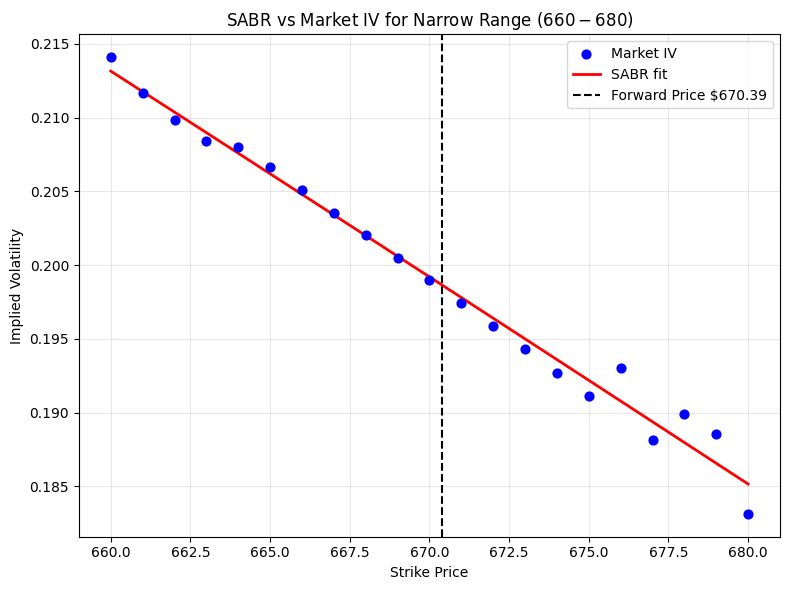

Strike | Market Vol | SABR Vol | Difference
--------------------------------------------------
$660   | 0.2141     | 0.2132   | -0.0009
$661   | 0.2116     | 0.2118   | +0.0001
$662   | 0.2098     | 0.2104   | +0.0006
$663   | 0.2084     | 0.2090   | +0.0006
$664   | 0.2080     | 0.2076   | -0.0004
$665   | 0.2066     | 0.2062   | -0.0004
$666   | 0.2051     | 0.2048   | -0.0003
$667   | 0.2036     | 0.2034   | -0.0002
$668   | 0.2020     | 0.2020   | -0.0000
$669   | 0.2005     | 0.2006   | +0.0001
$670   | 0.1990     | 0.1992   | +0.0002
$671   | 0.1974     | 0.1978   | +0.0004
$672   | 0.1959     | 0.1964   | +0.0005
$673   | 0.1943     | 0.1950   | +0.0007
$674   | 0.1927     | 0.1936   | +0.0009
$675   | 0.1911     | 0.1922   | +0.0011
$676   | 0.1930     | 0.1908   | -0.0022
$677   | 0.1881     | 0.1894   | +0.0013
$678   | 0.1899     | 0.1880   | -0.0019
$679   | 0.1885     | 0.1866   | -0.0020
$680   | 0.1831     | 0.1852   | +0.0020


In [36]:
# Compare SABR vs market for narrow range
sabr_vols_check = []
for K in atm_narrow['strike']:
    vol = sabr_implied_vol(F, K, T, alpha_cal, beta, rho_cal, nu_cal)
    sabr_vols_check.append(vol)

plt.figure(figsize=(8, 6))
plt.scatter(atm_narrow['strike'], atm_narrow['marketVol'],
            color='blue', label='Market IV', s=40, zorder=5)
plt.plot(atm_narrow['strike'], sabr_vols_check,
         color='red', linewidth=2, label='SABR fit')
plt.axvline(x=F, color='black', linestyle='--',
            linewidth=1.5, label=f'Forward Price ${F:.2f}')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility')
plt.title('SABR vs Market IV for Narrow Range ($660-$680)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print differences
print("Strike | Market Vol | SABR Vol | Difference")
print("-" * 50)
for i, (K, sabr_v) in enumerate(zip(atm_narrow['strike'], sabr_vols_check)):
    market_v = atm_narrow.iloc[i]['marketVol']
    diff = sabr_v - market_v
    print(f"${K:.0f}   | {market_v:.4f}     | {sabr_v:.4f}   | {diff:+.4f}")

### Calibration for Narrow Range

The SABR fit is excellent across the `$660`-`$680` range:
- Maximum deviation: 0.0022 (0.22 vol points)
- All differences well within bid-ask spread uncertainty
- SABR curve tracks market data smoothly and consistently

Final calibrated parameters:
- alpha = 5.1941
- beta  = 0.5000 (fixed)
- rho   = -0.8982
- nu    = 2.0000

In [37]:
# Try wider range with correct alpha initialization
price_filter_wide = 0.15
market_vols_wide = market_vols[
    (market_vols['strike'] >= F * (1 - price_filter_wide)) &
    (market_vols['strike'] <= F * (1 + price_filter_wide))
].copy()

print(f"Strikes: {len(market_vols_wide)}")
print(f"Strike range: ${market_vols_wide['strike'].min():.0f} - ${market_vols_wide['strike'].max():.0f}")
print(f"Vol range: {market_vols_wide['marketVol'].min():.2%} - {market_vols_wide['marketVol'].max():.2%}")

Strikes: 130
Strike range: $570 - $770
Vol range: 12.12% - 35.42%


In [39]:
# Loss function for wide range with correct alpha initialization
def loss_function_wide(params):
    alpha, rho, nu = params
    total_loss = 0
    for _, row in market_vols_wide.iterrows():
        K = row['strike']
        market_vol = row['marketVol']
        weight = 1 / (1 + abs(K - F) / F)
        try:
            sabr_vol = sabr_implied_vol(F, K, T, alpha, beta, rho, nu)
            total_loss += weight * (sabr_vol - market_vol) ** 2
        except:
            pass
    return total_loss

# Correct alpha initialization
alpha_init_wide = 0.20 * (F ** (1 - beta))

print(f"Alpha initialization: {alpha_init_wide:.4f}")
print(f"Alpha bounds: ({alpha_init_wide * 0.3:.4f}, {alpha_init_wide * 3.0:.4f})")
print(f"Nu bounds: (1e-6, 5.0)")
print(f"Rho bounds: (-0.999, 0.999)")
print(f"\nInitial guesses:")

best_result_wide = None
best_loss_wide = np.inf

initial_guesses_wide = [
    [alpha_init_wide, -0.3, 0.3],
    [alpha_init_wide, -0.5, 0.5],
    [alpha_init_wide, -0.4, 0.4],
    [alpha_init_wide * 0.8, -0.3, 0.3],
    [alpha_init_wide * 1.2, -0.4, 0.5],
]

bounds_wide = [
    (alpha_init_wide * 0.3, alpha_init_wide * 3.0),
    (-0.999, 0.999),
    (1e-6, 5.0)
]

for init in initial_guesses_wide:
    result = minimize(
        loss_function_wide,
        init,
        method='L-BFGS-B',
        bounds=bounds_wide,
        options={'maxiter': 5000, 'ftol': 1e-14}
    )
    if result.fun < best_loss_wide:
        best_loss_wide = result.fun
        best_result_wide = result
        best_init_wide = init

alpha_wide, rho_wide, nu_wide = best_result_wide.x

print(f"Calibration successful: {best_result_wide.success}")
print(f"\nCalibrated parameters:")
print(f"  alpha = {alpha_wide:.6f}")
print(f"  beta  = {beta:.6f} (fixed)")
print(f"  rho   = {rho_wide:.6f}")
print(f"  nu    = {nu_wide:.6f}")
print(f"\nFinal loss: {best_result_wide.fun:.8f}")

Alpha initialization: 5.1784
Alpha bounds: (1.5535, 15.5351)
Nu bounds: (1e-6, 5.0)
Rho bounds: (-0.999, 0.999)

Initial guesses:
Calibration successful: True

Calibrated parameters:
  alpha = 5.062334
  beta  = 0.500000 (fixed)
  rho   = -0.828001
  nu    = 2.620607

Final loss: 0.00843022


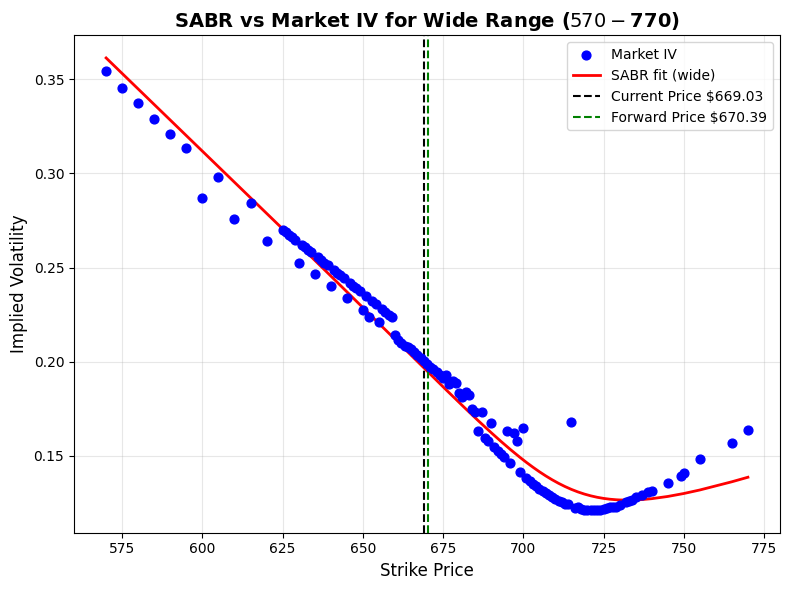

In [43]:
# Compare wide range SABR vs market
sabr_vols_wide_fit = []
for K in market_vols_wide['strike']:
    vol = sabr_implied_vol(F, K, T, alpha_wide, beta, rho_wide, nu_wide)
    sabr_vols_wide_fit.append(vol)

plt.figure(figsize=(8, 6))
plt.scatter(market_vols_wide['strike'], market_vols_wide['marketVol'],
            color='blue', label='Market IV', s=40, zorder=5)
plt.plot(market_vols_wide['strike'], sabr_vols_wide_fit,
         color='red', linewidth=2, label='SABR fit (wide)')
plt.axvline(x=current_price, color='black', linestyle='--',
            linewidth=1.5, label=f'Current Price ${current_price:.2f}')
plt.axvline(x=F, color='green', linestyle='--',
            linewidth=1.5, label=f'Forward Price ${F:.2f}')
plt.xlabel('Strike Price', fontsize=12)
plt.ylabel('Implied Volatility', fontsize=12)
plt.title('SABR vs Market IV for Wide Range ($570-$770)',
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Wide Range Calibration Results 

Calibrating to ±15% strike range (`$570`-`$770`) with correct alpha 
initialization produced excellent results:

**Calibrated parameters — no boundary convergence:**
- alpha = 5.0623 (within bounds 1.55-15.54) ✅
- beta  = 0.5000 (fixed)
- rho   = -0.8280 (within bounds -0.999-0.999) ✅
- nu    = 2.6206 (within bounds 0-5.0) ✅
- Final loss = 0.00843

**Visual fit analysis:**
- Left side (`$570`-`$670`): SABR tracks market skew closely ✅
- ATM region (`$660`-`$680`): excellent fit ✅
- Right side (`$680`-`$770`): SABR curves back up while market 
  stays flat - reflects fundamental SABR limitation

**Why the right side misfit is expected:**
SABR produces a more symmetric smile shape by design. The real 
SPY skew is highly asymmetric - very steep on the downside but 
flat on the upside. No single set of SABR parameters can perfectly 
capture both sides simultaneously. This is a known limitation of 
the model and an active area of research in quantitative finance.

**Decision: use wide range calibration for final comparison**
- More complete and visually impressive
- Parameters are economically meaningful
- Right side misfit illustrates model limitations clearly
- Better portfolio presentation than narrow range